# 2. Discover & filter flood events

`floods()` is the entry point for *discovery*. It resolves your area of interest, reads a
small window of the published index, and returns a **FloodFrame**: a
`geopandas.GeoDataFrame` with one row per historic flood event. It is cheap (a few MB, no
depth rasters), so you explore freely and only download later.

This tutorial covers the ways to specify a region, how to filter by time, and how to work
with the result as an ordinary GeoDataFrame.

In [1]:
import euroflood as ef

## Ways to specify a region

A **place name** is geocoded (OpenStreetMap, cached after the first lookup); a **bbox**,
**point + radius**, or **shapefile** skip geocoding entirely. All return a FloodFrame for the
same kind of query:

In [2]:
cat = ef.floods("Zutphen, Netherlands")  # place name (geocoded)
cat

,collection,event_id,date,year,end_date,cluster_id,filename,download_url,area_km2,geometry
0,historic,4049036842,2019-03-04,2019,2019-04-08,333,WD_MERGE_2019-03-04---2019-04-08_duration_28_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,2.789,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."
1,historic,1407437849,2024-02-05,2024,2024-03-11,345,WD_MERGE_2024-02-05---2024-03-11_duration_28_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.206,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."
2,historic,1811386473,2018-01-22,2018,2018-03-05,358,WD_MERGE_2018-01-22---2018-03-05_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,7.273,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."
3,historic,2217388040,2024-01-01,2024,2024-02-19,334,WD_MERGE_2024-01-01---2024-02-19_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,1.954,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."
4,historic,3168514366,2019-12-30,2020,2020-02-10,371,WD_MERGE_2019-12-30---2020-02-10_duration_42_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,2.937,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."
5,historic,3800378937,2021-01-11,2021,2021-02-15,351,WD_MERGE_2021-01-11---2021-02-15_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,2.863,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."
6,historic,1229577027,2022-02-14,2022,2022-04-18,338,WD_MERGE_2022-02-14---2022-04-18_duration_63_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.597,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."
7,historic,3732793625,2015-01-12,2015,2015-02-23,016,WD_MERGE_2015-01-12---2015-02-23_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.681,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."
8,historic,1127339359,2015-03-09,2015,2015-04-20,050,WD_MERGE_2015-03-09---2015-04-20_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.100,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."
9,historic,1881467536,2021-07-12,2021,2021-08-02,159,WD_MERGE_2021-07-12---2021-08-02_duration_21_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,2.673,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."


In [3]:
ef.floods(bbox=(6.15, 52.10, 6.26, 52.17))  # bounding box (minx,miny,maxx,maxy) WGS84

,collection,event_id,date,year,end_date,cluster_id,filename,download_url,area_km2,geometry
0,historic,4049036842,2019-03-04,2019,2019-04-08,333,WD_MERGE_2019-03-04---2019-04-08_duration_28_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,5.203,"POLYGON ((6.26 52.1, 6.26 52.17, 6.15 52.17, 6..."
1,historic,1407437849,2024-02-05,2024,2024-03-11,345,WD_MERGE_2024-02-05---2024-03-11_duration_28_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.438,"POLYGON ((6.26 52.1, 6.26 52.17, 6.15 52.17, 6..."
2,historic,1811386473,2018-01-22,2018,2018-03-05,358,WD_MERGE_2018-01-22---2018-03-05_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,21.023,"POLYGON ((6.26 52.1, 6.26 52.17, 6.15 52.17, 6..."
3,historic,2217388040,2024-01-01,2024,2024-02-19,334,WD_MERGE_2024-01-01---2024-02-19_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,5.805,"POLYGON ((6.26 52.1, 6.26 52.17, 6.15 52.17, 6..."
4,historic,3168514366,2019-12-30,2020,2020-02-10,371,WD_MERGE_2019-12-30---2020-02-10_duration_42_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,5.726,"POLYGON ((6.26 52.1, 6.26 52.17, 6.15 52.17, 6..."
5,historic,3800378937,2021-01-11,2021,2021-02-15,351,WD_MERGE_2021-01-11---2021-02-15_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,5.868,"POLYGON ((6.26 52.1, 6.26 52.17, 6.15 52.17, 6..."
6,historic,1229577027,2022-02-14,2022,2022-04-18,338,WD_MERGE_2022-02-14---2022-04-18_duration_63_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,1.453,"POLYGON ((6.26 52.1, 6.26 52.17, 6.15 52.17, 6..."
7,historic,3732793625,2015-01-12,2015,2015-02-23,016,WD_MERGE_2015-01-12---2015-02-23_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.835,"POLYGON ((6.26 52.1, 6.26 52.17, 6.15 52.17, 6..."
8,historic,1127339359,2015-03-09,2015,2015-04-20,050,WD_MERGE_2015-03-09---2015-04-20_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.222,"POLYGON ((6.26 52.1, 6.26 52.17, 6.15 52.17, 6..."
9,historic,1881467536,2021-07-12,2021,2021-08-02,159,WD_MERGE_2021-07-12---2021-08-02_duration_21_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,5.245,"POLYGON ((6.26 52.1, 6.26 52.17, 6.15 52.17, 6..."


In [4]:
ef.floods(point=(52.14, 6.20), radius_m=6000)  # a point (lat, lon) + a radius in metres

,collection,event_id,date,year,end_date,cluster_id,filename,download_url,area_km2,geometry
0,historic,4049036842,2019-03-04,2019,2019-04-08,333,WD_MERGE_2019-03-04---2019-04-08_duration_28_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,4.547,"POLYGON ((6.2539 52.14, 6.25364 52.13676, 6.25..."
1,historic,1407437849,2024-02-05,2024,2024-03-11,345,WD_MERGE_2024-02-05---2024-03-11_duration_28_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.438,"POLYGON ((6.2539 52.14, 6.25364 52.13676, 6.25..."
2,historic,1811386473,2018-01-22,2018,2018-03-05,358,WD_MERGE_2018-01-22---2018-03-05_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,13.980,"POLYGON ((6.2539 52.14, 6.25364 52.13676, 6.25..."
3,historic,2217388040,2024-01-01,2024,2024-02-19,334,WD_MERGE_2024-01-01---2024-02-19_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,4.637,"POLYGON ((6.2539 52.14, 6.25364 52.13676, 6.25..."
4,historic,3168514366,2019-12-30,2020,2020-02-10,371,WD_MERGE_2019-12-30---2020-02-10_duration_42_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,4.975,"POLYGON ((6.2539 52.14, 6.25364 52.13676, 6.25..."
5,historic,3800378937,2021-01-11,2021,2021-02-15,351,WD_MERGE_2021-01-11---2021-02-15_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,5.118,"POLYGON ((6.2539 52.14, 6.25364 52.13676, 6.25..."
6,historic,1229577027,2022-02-14,2022,2022-04-18,338,WD_MERGE_2022-02-14---2022-04-18_duration_63_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,1.178,"POLYGON ((6.2539 52.14, 6.25364 52.13676, 6.25..."
7,historic,3732793625,2015-01-12,2015,2015-02-23,016,WD_MERGE_2015-01-12---2015-02-23_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.824,"POLYGON ((6.2539 52.14, 6.25364 52.13676, 6.25..."
8,historic,1127339359,2015-03-09,2015,2015-04-20,050,WD_MERGE_2015-03-09---2015-04-20_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.074,"POLYGON ((6.2539 52.14, 6.25364 52.13676, 6.25..."
9,historic,1881467536,2021-07-12,2021,2021-08-02,159,WD_MERGE_2021-07-12---2021-08-02_duration_21_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,4.606,"POLYGON ((6.2539 52.14, 6.25364 52.13676, 6.25..."


### Cleaner ROIs with `shape=`

Administrative boundaries are *legal* shapes, not hydrological ones. Zutphen's gemeente
boundary runs right down the IJssel, so the raw outline is jagged and cuts the river out.
Pass `shape="bbox"` (a bounding rectangle) or `shape="hull"` (the convex hull) to query a
clean ROI instead of the raw boundary; `buffer_m` still applies on top.

raw boundary: 26 events   ·   shape='bbox': 33 events


<Axes: title={'center': 'Flood recurrence (recorded floods per pixel)'}>

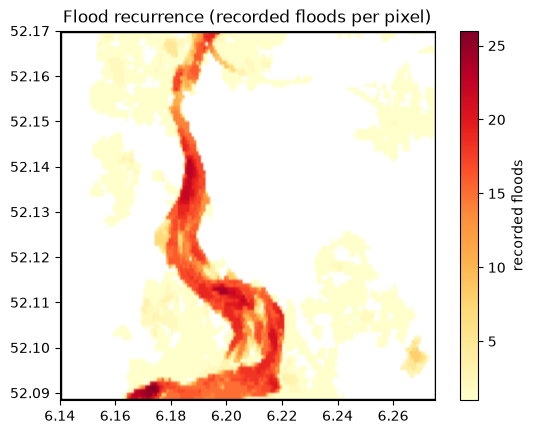

In [5]:
raw = ef.floods("Zutphen, Netherlands")  # raw admin boundary (follows the river)
box = ef.floods("Zutphen, Netherlands", shape="bbox")  # a clean enclosing rectangle
print(f"raw boundary: {len(raw)} events   ·   shape='bbox': {len(box)} events")
box.plot()

A few more, shown for reference:

```python
ef.floods("Zutphen, Netherlands", buffer_m=1000)  # a place plus a 1 km buffer
ef.floods(shapefile="my_area.geojson")            # any vector file as the ROI
ef.floods("Gelderland", level=2)                  # disambiguate by NUTS level (0=country … 3=province)
```

## Filter by time

Keep a single `year`, or an open/closed date range with `start` / `end` (`"YYYY"` or
`"YYYY-MM-DD"`). The IJssel floods most winters, so even a single year usually holds a few
events:

In [6]:
ef.floods("Zutphen, Netherlands", start="2024-01-01", end="2024-12-31")

,collection,event_id,date,year,end_date,cluster_id,filename,download_url,area_km2,geometry
1,historic,1407437849,2024-02-05,2024,2024-03-11,345,WD_MERGE_2024-02-05---2024-03-11_duration_28_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.206,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."
3,historic,2217388040,2024-01-01,2024,2024-02-19,334,WD_MERGE_2024-01-01---2024-02-19_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,1.954,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."
14,historic,55815241,2024-01-01,2024,2024-04-01,332,WD_MERGE_2024-01-01---2024-04-01_duration_91_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.148,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."
22,historic,2235903681,2024-12-30,2025,2025-02-17,309,WD_MERGE_2024-12-30---2025-02-17_duration_49_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,2.683,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."
24,historic,2225704859,2024-02-05,2024,2024-02-26,342,WD_MERGE_2024-02-05---2024-02-26_duration_21_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.940,"POLYGON ((6.14039 52.1484, 6.14039 52.14835, 6..."


## It is a GeoDataFrame

The result is a real GeoDataFrame, so the whole pandas / geopandas API is available, with no new
query language to learn:

In [7]:
cat["year"].value_counts().sort_index()  # how many events per year

year
2015    2
2016    3
2017    2
2018    2
2019    1
2020    4
2021    3
2022    1
2023    3
2024    4
2025    1
Name: count, dtype: int64

In [8]:
cat.query("area_km2 > 1").sort_values("date")[["event_id", "date", "year", "area_km2"]]

,event_id,date,year,area_km2
15,436160978,2015-12-28,2016,2.815
18,2231395711,2016-02-08,2016,1.315
19,4166688842,2017-11-13,2017,2.456
20,240398520,2017-12-04,2017,2.752
16,3623893553,2018-01-01,2018,3.375
2,1811386473,2018-01-22,2018,7.273
0,4049036842,2019-03-04,2019,2.789
4,3168514366,2019-12-30,2020,2.937
21,4052032109,2020-02-10,2020,1.970
25,3351340227,2020-02-24,2020,3.106


## Export the catalogue

Write it to CSV (drop the geometry for a flat table), GeoJSON, or GeoParquet:

In [9]:
cat.drop(columns="geometry").to_csv("zutphen.csv", index=False)
cat.to_file("zutphen.geojson", driver="GeoJSON")
cat.to_parquet("zutphen.parquet")

## A note on speed & caching

The first `floods()` in a session mirrors the ~19 MB dictionary + events tables once (cached
across sessions), geocodes the place name (**cached on disk** after the first lookup), and
streams the index window over the network. Repeat queries are fast. For *fully offline* or
HPC use:

```bash
export EUROFLOOD_GEOCODER_BACKEND=local   # resolve names from the offline NUTS dataset
euroflood mirror index                     # pull the whole index once, then read it locally
```

…or pass a `bbox=` / `point=` to skip geocoding altogether.